We do the CVE rate-outbreak for 2025 using logistic regression and nonnegative binomial regression. We also tested with only CVE and enrollment, is additive or multiplicative better? Besides, should we offset by population or enrollment? 

In [1]:
# load environment
library(tidyverse)
library(dplyr)


Warning message:
"Paket 'ggplot2' wurde unter R Version 4.4.3 erstellt"
Warning message:
"Paket 'forcats' wurde unter R Version 4.4.1 erstellt"
-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.1     v stringr   1.5.1
v ggplot2   4.0.2     v tibble    3.2.1
v lubridate 1.9.3     v tidyr     1.3.1
v purrr     1.0.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
# loading data
outbreak <- read.csv("data/raw/base/Outbreak.csv")
cve <- read.csv("data/raw/base/CVE.csv")

In [4]:
df <- cve %>%
  inner_join(outbreak, by = "County",
             suffix = c("_cve", "_out"))

In [5]:
head(df)

,County,X2016_cve,X2017_cve,X2018_cve,X2019_cve,X2020_cve,X2021_cve,X2022_cve,X2023_cve,X2024_cve,...,X2016_out,X2017_out,X2018_out,X2019_out,X2020_out,X2021_out,X2022_out,X2023_out,X2024_out,X2025_out
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,Anderson,0.35%,0.50%,0.75%,0.94%,1.00%,1.11%,1.62%,1.64%,2.05%,...,0,0,0,0,0,0,0,0,0,0
2,Andrews,0.75%,0.90%,1.07%,1.50%,0.39%,1.36%,0.45%,1.57%,1.43%,...,0,0,0,0,0,0,0,0,0,1
3,Angelina,0.70%,0.63%,0.67%,0.82%,0.96%,0.86%,1.03%,1.53%,1.98%,...,0,0,0,0,0,0,0,0,0,0
4,Aransas,1.22%,1.39%,1.49%,1.71%,1.57%,1.51%,0.00%,1.91%,1.91%,...,0,0,0,0,0,0,0,0,0,0
5,Archer,0.61%,0.45%,0.81%,1.43%,1.29%,1.56%,1.68%,2.32%,2.80%,...,0,0,0,0,0,0,0,0,0,0
6,Armstrong,0.59%,1.90%,1.44%,2.35%,3.53%,3.53%,3.77%,4.46%,4.95%,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df2025 <- df %>%
  transmute(
    County,
    cve = `X2025_cve`,
    outbreak = `X2025_out`
  )


In [7]:
df2025$cve <- gsub("%", "", df2025$cve)
df2025$cve <- as.numeric(df2025$cve)

In [8]:

# convert to binary: any outbreak (> 0) = 1, no outbreak = 0
df2025$outbreak <- as.numeric(df2025$outbreak > 0)


In [9]:
# perform logistic regression
lr <- glm(outbreak ~ cve, data = df2025, family = "binomial")

In [10]:
coef(lr)
summary(lr)

(Intercept)         cve 
 -2.2174213   0.1480485


Call:
glm(formula = outbreak ~ cve, family = "binomial", data = df2025)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.21742    0.31207  -7.105  1.2e-12 ***
cve          0.14805    0.07904   1.873    0.061 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 210.88  on 253  degrees of freedom
Residual deviance: 207.56  on 252  degrees of freedom
AIC: 211.56

Number of Fisher Scoring iterations: 4


In [12]:
count <- read.csv("data/raw/base/Count.csv")

df <- cve %>%
  inner_join(count, by = "County",
             suffix = c("_cve", "_count"))
df2025 <- df %>%
  transmute(
    County,
    cve = `X2025_cve`,
    outbreak = `X2025_count`
  )
df2025$cve <- gsub("%", "", df2025$cve)
df2025$cve <- as.numeric(df2025$cve)
pr <- glm(outbreak ~ cve, data = df2025, family = "poisson")
coef(pr)
summary(pr)

(Intercept)         cve 
 -1.3823001   0.4866783


Call:
glm(formula = outbreak ~ cve, family = "poisson", data = df2025)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.382300   0.078298  -17.65   <2e-16 ***
cve          0.486678   0.007494   64.94   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 5469.3  on 253  degrees of freedom
Residual deviance: 2443.2  on 252  degrees of freedom
AIC: 2567.9

Number of Fisher Scoring iterations: 8


In [14]:
enrollment <- read.csv("data/raw/base/Enrollment.csv")

enrollment <- enrollment %>%
  mutate(
    County = County %>%
      str_to_lower() %>%
      str_remove(" county") %>%
      str_trim() %>%
      str_to_title()
  )
enrollment <- enrollment[enrollment$County != "Grand Total", ]
View(enrollment)

,County,Enrollment.Sum
,<chr>,<int>
1,Anderson,7808
2,Andrews,4209
3,Angelina,15649
4,Aransas,2913
5,Archer,2110
6,Armstrong,297
7,Atascosa,9046
8,Austin,6290
9,Bailey,1330


In [15]:
df2025 <- df2025 %>%
  left_join(enrollment, by = "County") %>%
  transmute(
    County,
    cve,
    outbreak,
    enrollment = Enrollment.Sum
  )
View(df2025)
pr <- glm(outbreak ~ cve, data = df2025, family = "gaussian")
summary(pr)

County,cve,outbreak,enrollment
<chr>,<dbl>,<int>,<int>
Anderson,2.54,0,7808
Andrews,1.91,3,4209
Angelina,2.50,0,15649
Aransas,2.06,0,2913
Archer,2.70,0,2110
Armstrong,5.24,0,297
Atascosa,1.08,1,9046
Austin,3.55,0,6290
Bailey,0.80,2,1330



Call:
glm(formula = outbreak ~ cve, family = "gaussian", data = df2025)

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -10.3494     2.7245  -3.799 0.000182 ***
cve           4.7119     0.7892   5.970    8e-09 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for gaussian family taken to be 629.8196)

    Null deviance: 181166  on 253  degrees of freedom
Residual deviance: 158715  on 252  degrees of freedom
AIC: 2362

Number of Fisher Scoring iterations: 2


In [17]:
library(dplyr)

county_population <- read.csv("data/raw/base/population.csv") 

df2025 <- df2025 %>%
  left_join(county_population, by = "County") %>%
  transmute(
    County,
    cve,
    outbreak,
    enrollment,
    population = `X2025_pop`
  )

# View(df2025)

df2025 <- df2025 %>%
  mutate(
    enrollment = as.numeric(enrollment),
    population = as.numeric(population),
    enrollment_per_capita = enrollment / population
  )

# View(df2025)
pr_1 <- glm(outbreak ~ cve * enrollment, data = df2025, family = "poisson")
summary(pr_1)

pr_2 <- glm(outbreak ~ cve * enrollment_per_capita, data = df2025, family = "poisson")
summary(pr_2)

b <- coef(pr_2)

b_cve  <- b["cve"]
b_int  <- b["cve:enrollment_per_capita"]

epc_vals <- c(0.03, 0.06, 0.10)

log_effect <- b_cve + b_int * epc_vals
irr <- exp(log_effect)

data.frame(
  EPC = epc_vals,
  Log_Effect = log_effect,
  Incidence_Rate_Ratio = irr
)


Call:
glm(formula = outbreak ~ cve * enrollment, family = "poisson", 
    data = df2025)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -1.620e+00  8.778e-02  -18.46   <2e-16 ***
cve             5.407e-01  9.177e-03   58.92   <2e-16 ***
enrollment      2.395e-05  1.656e-06   14.46   <2e-16 ***
cve:enrollment -1.183e-05  9.664e-07  -12.24   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 5437.8  on 248  degrees of freedom
Residual deviance: 2214.3  on 245  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 2338.9

Number of Fisher Scoring iterations: 10



Call:
glm(formula = outbreak ~ cve * enrollment_per_capita, family = "poisson", 
    data = df2025)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)               -2.36043    0.20680 -11.414  < 2e-16 ***
cve                        0.81670    0.04823  16.932  < 2e-16 ***
enrollment_per_capita      6.12466    1.08064   5.668 1.45e-08 ***
cve:enrollment_per_capita -2.00462    0.28857  -6.947 3.73e-12 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 5437.8  on 248  degrees of freedom
Residual deviance: 2306.2  on 245  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 2430.9

Number of Fisher Scoring iterations: 8


EPC,Log_Effect,Incidence_Rate_Ratio
<dbl>,<dbl>,<dbl>
0.03,0.7565657,2.130945
0.06,0.6964271,2.006571
0.10,0.6162421,1.851956


In [18]:
#poisson offset

pr_offset <- glm(
  outbreak ~ cve + enrollment_per_capita,
  family = "poisson",
  offset = log(population),
  data = df2025
)
summary(pr_offset)

overdispersion <- deviance(pr_offset) / df.residual(pr_offset)
print(overdispersion)


Call:
glm(formula = outbreak ~ cve + enrollment_per_capita, family = "poisson", 
    data = df2025, offset = log(population))

Coefficients:
                        Estimate Std. Error  z value Pr(>|z|)    
(Intercept)           -13.988507   0.129887 -107.697  < 2e-16 ***
cve                     0.638767   0.006834   93.464  < 2e-16 ***
enrollment_per_capita   3.561623   0.562455    6.332 2.42e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 7303.4  on 248  degrees of freedom
Residual deviance: 2549.5  on 246  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 2672.2

Number of Fisher Scoring iterations: 10


[1] 10.36388


In [19]:
# nb, population offset, interactive
df2025 <- df2025 %>%
  mutate(
    cve_c = cve - mean(cve, na.rm = TRUE),
    epc_c = enrollment_per_capita - mean(enrollment_per_capita, na.rm = TRUE)
  )

library(MASS)

nb <- glm.nb(
  outbreak ~ cve_c * epc_c + offset(log(population)),
  data = df2025
)
summary(nb)

# b <- coef(nb)

# b1 <- b["cve_c"]
# b3 <- b["cve_c:epc_c"]

# epc_seq <- seq(
#   min(df2025$epc_c, na.rm=TRUE),
#   max(df2025$epc_c, na.rm=TRUE),
#   length.out = 100
# )

# log_effect <- b1 + b3 * epc_seq
# irr <- exp(log_effect)

# plot(epc_seq, irr, type="l",
#      xlab="Centered Enrollment per Capita",
#      ylab="IRR of CVE")
# abline(h=1, col="red")

# nb, population offset, additive
nb_add <- glm.nb(
  outbreak ~ cve_c + epc_c + offset(log(population)),
  data = df2025)
summary(nb_add)

# b <- coef(nb_add)

# irr_cve <- exp(b["cve_c"])

# epc_seq <- seq(
#   min(df2025$epc_c, na.rm = TRUE),
#   max(df2025$epc_c, na.rm = TRUE),
#   length.out = 100
# )

# irr_flat <- rep(irr_cve, length(epc_seq))

# plot(epc_seq, irr_flat, type = "l",
#      xlab = "Centered Enrollment per Capita",
#      ylab = "IRR of CVE",
#      main = "Constant Effect of CVE (Additive NB Model)")
# abline(h = 1, col = "red")

# nb, enrollment offset, interactive
nb_enr_int <- glm.nb(
  outbreak ~ cve_c * epc_c + offset(log(enrollment)),
  data = df2025
)
summary(nb_enr_int)

# nb, enrollment offset, additive
nb_enr_add <- glm.nb(
  outbreak ~ cve_c + epc_c + offset(log(enrollment)),
  data = df2025
)
summary(nb_enr_add)

AIC(nb, nb_add, nb_enr_int, nb_enr_add)



Attache Paket: 'MASS'


Das folgende Objekt ist maskiert 'package:dplyr':

    select


Warning message:
"glm.fit: Algorithmus konvergierte nicht"



Call:
glm.nb(formula = outbreak ~ cve_c * epc_c + offset(log(population)), 
    data = df2025, init.theta = 0.04579444703, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -9.7723     0.3135 -31.171  < 2e-16 ***
cve_c         0.4903     0.1571   3.121 0.001805 ** 
epc_c        13.1493     3.5822   3.671 0.000242 ***
cve_c:epc_c   0.5797     2.4037   0.241 0.809420    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0458) family taken to be 1)

    Null deviance: 102.191  on 248  degrees of freedom
Residual deviance:  80.707  on 245  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 420.21

Number of Fisher Scoring iterations: 1


              Theta:  0.04579 
          Std. Err.:  0.00900 

 2 x log-likelihood:  -410.20800 

Warning message:
"glm.fit: Algorithmus konvergierte nicht"



Call:
glm.nb(formula = outbreak ~ cve_c + epc_c + offset(log(population)), 
    data = df2025, init.theta = 0.04577838996, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -9.7737     0.3134 -31.183  < 2e-16 ***
cve_c         0.4874     0.1570   3.105 0.001905 ** 
epc_c        13.4153     3.5044   3.828 0.000129 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0458) family taken to be 1)

    Null deviance: 102.162  on 248  degrees of freedom
Residual deviance:  80.696  on 246  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 418.22

Number of Fisher Scoring iterations: 1


              Theta:  0.04578 
          Std. Err.:  0.00899 

 2 x log-likelihood:  -410.21900 

Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"



Call:
glm.nb(formula = outbreak ~ cve_c * epc_c + offset(log(enrollment)), 
    data = df2025, init.theta = 0.04655616568, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -8.0977     0.3114 -26.003  < 2e-16 ***
cve_c         0.4927     0.1560   3.159  0.00158 ** 
epc_c         8.0958     3.5573   2.276  0.02286 *  
cve_c:epc_c   0.6299     2.3872   0.264  0.79189    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0466) family taken to be 1)

    Null deviance: 103.030  on 248  degrees of freedom
Residual deviance:  80.852  on 245  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 419.32

Number of Fisher Scoring iterations: 1


              Theta:  0.04656 
          Std. Err.:  0.00917 

 2 x log-likelihood:  -409.32100 

Warning message:
"glm.fit: Algorithmus konvergierte nicht"
Warning message:
"glm.fit: Algorithmus konvergierte nicht"



Call:
glm.nb(formula = outbreak ~ cve_c + epc_c + offset(log(enrollment)), 
    data = df2025, init.theta = 0.04653594373, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -8.0993     0.3114 -26.013  < 2e-16 ***
cve_c         0.4899     0.1559   3.143  0.00167 ** 
epc_c         8.4056     3.4801   2.415  0.01572 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0465) family taken to be 1)

    Null deviance: 102.993  on 248  degrees of freedom
Residual deviance:  80.838  on 246  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 417.33

Number of Fisher Scoring iterations: 1


              Theta:  0.04654 
          Std. Err.:  0.00916 

 2 x log-likelihood:  -409.33500 

,df,AIC
,<dbl>,<dbl>
nb,5,420.2080
nb_add,4,418.2188
nb_enr_int,5,419.3211
nb_enr_add,4,417.3347


In [20]:
summary_table <- df2025 %>%
  summarise(
    outbreak_mean = mean(outbreak, na.rm = TRUE),
    outbreak_sd   = sd(outbreak, na.rm = TRUE),
    outbreak_min  = min(outbreak, na.rm = TRUE),
    outbreak_max  = max(outbreak, na.rm = TRUE),

    cve_mean = mean(cve, na.rm = TRUE),
    cve_sd   = sd(cve, na.rm = TRUE),
    cve_min  = min(cve, na.rm = TRUE),
    cve_max  = max(cve, na.rm = TRUE),

    epc_mean = mean(enrollment_per_capita, na.rm = TRUE),
    epc_sd   = sd(enrollment_per_capita, na.rm = TRUE),
    epc_min  = min(enrollment_per_capita, na.rm = TRUE),
    epc_max  = max(enrollment_per_capita, na.rm = TRUE),

    pop_mean = mean(population, na.rm = TRUE),
    pop_sd   = sd(population, na.rm = TRUE),
    pop_min  = min(population, na.rm = TRUE),
    pop_max  = max(population, na.rm = TRUE),

    enr_mean = mean(enrollment, na.rm = TRUE),
    enr_sd   = sd(enrollment, na.rm = TRUE),
    enr_min  = min(enrollment, na.rm = TRUE),
    enr_max  = max(enrollment, na.rm = TRUE)
  )

summary_table

outbreak_mean,outbreak_sd,outbreak_min,outbreak_max,cve_mean,cve_sd,cve_min,cve_max,epc_mean,epc_sd,epc_min,epc_max,pop_mean,pop_sd,pop_min,pop_max,enr_mean,enr_sd,enr_min,enr_max
<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2.925197,26.75947,0,414,2.817244,1.999215,0,14.54,0.1900911,0.08589193,0.07262002,1.001594,124300.4,438020.4,55,5003892,22023.25,76816.54,93,879002


Warning message:
"Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`)."


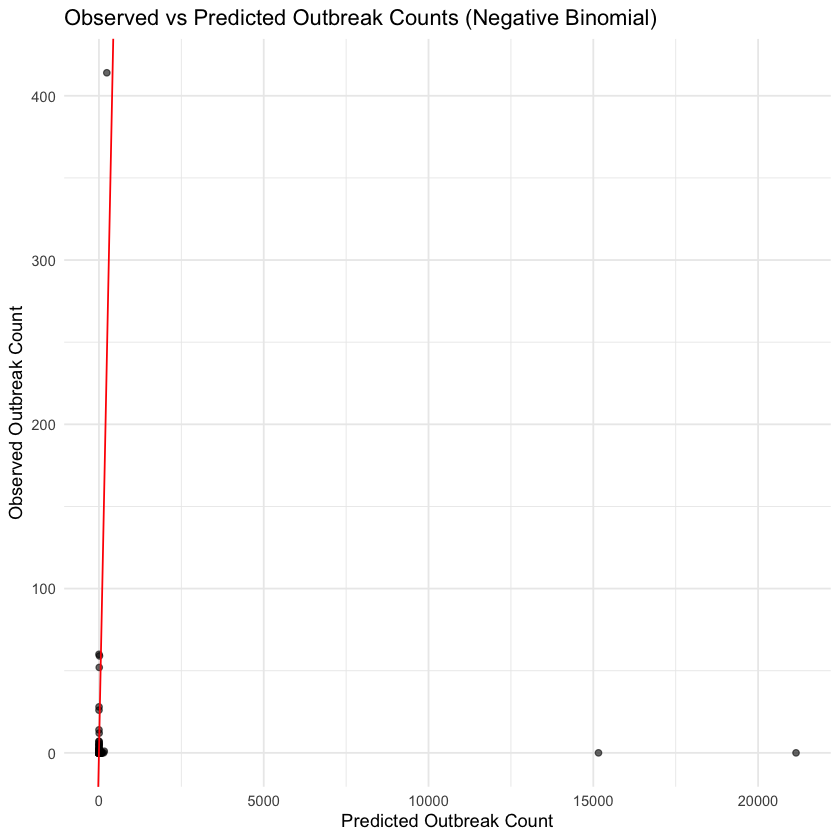

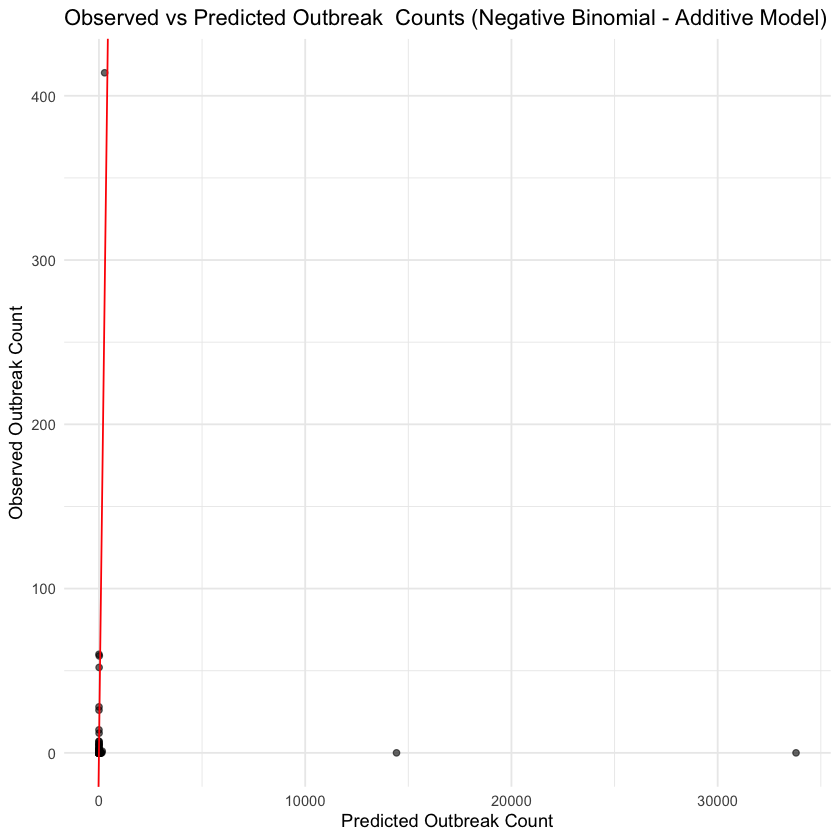

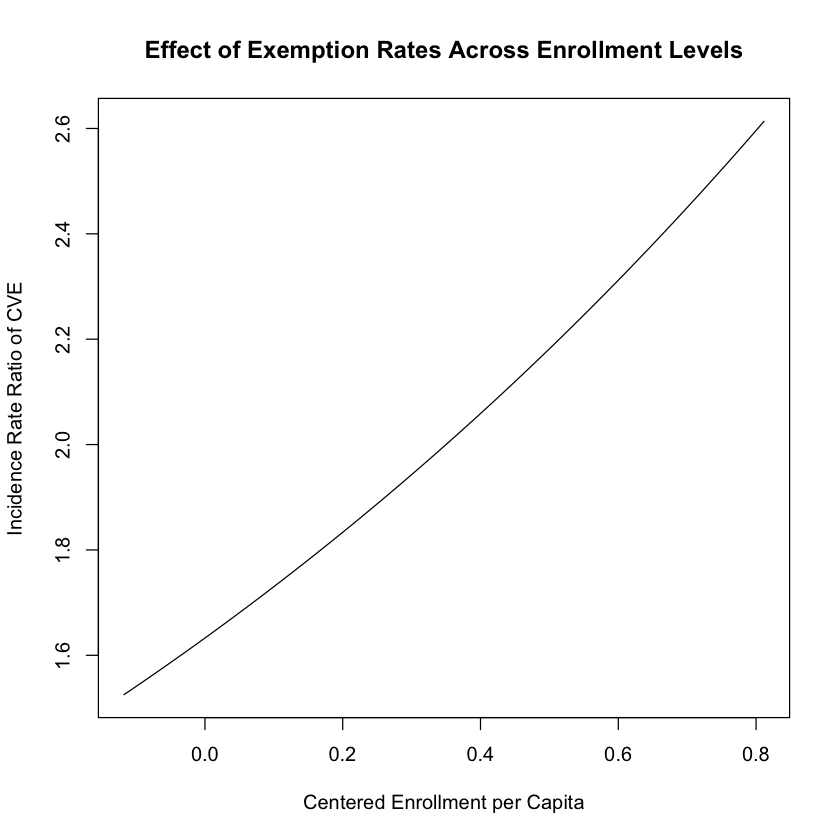

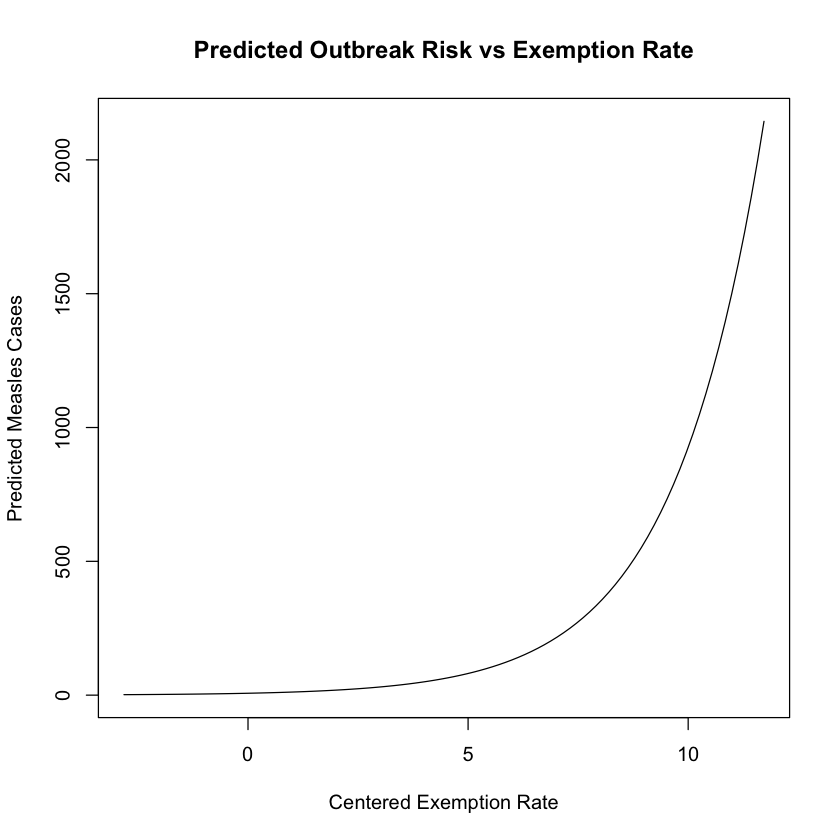

In [21]:
# pr offset
# df2025$mu_hat <- NA
# df2025$mu_hat[as.numeric(rownames(pr_offset$model))] <- fitted(pr_offset)

# library(dplyr)

# mv_plot <- df2025 %>%
#   mutate(mu_bin = cut(mu_hat, breaks = 10)) %>%
#   group_by(mu_bin) %>%
#   summarise(
#     mean_y = mean(outbreak),
#     var_y  = var(outbreak)
#   )

# library(ggplot2)

# ggplot(mv_plot, aes(x = mean_y, y = var_y)) +
#   geom_point(size = 3) +
#   geom_abline(intercept = 0, slope = 1, color = "red") +
#   labs(
#     title = "Mean–Variance Relationship",
#     x = "Mean Outbreak Count",
#     y = "Variance of Outbreak Count"
#   ) +
#   theme_minimal()


# plot(fitted(pr_offset),
#      residuals(pr_offset, type = "pearson"),
#      xlab = "Fitted values",
#      ylab = "Pearson residuals")
# abline(h = 0, col = "red")

# negative binomial

df2025$mu_nb <- predict(nb, newdata = df2025, type = "response")
ggplot(df2025, aes(x = mu_nb, y = outbreak)) +
  geom_point(alpha = 0.6) +
  geom_abline(slope = 1, intercept = 0, color = "red") +
  labs(
    title = "Observed vs Predicted Outbreak Counts (Negative Binomial)",
    x = "Predicted Outbreak Count",
    y = "Observed Outbreak Count"
  ) +
  theme_minimal()
  
df2025$mu_nb_add <- predict(nb_add, newdata = df2025, type = "response")
ggplot(df2025, aes(x = mu_nb_add, y = outbreak)) +
  geom_point(alpha = 0.6) +
  geom_abline(slope = 1, intercept = 0, color = "red") +
  labs(
    title = "Observed vs Predicted Outbreak  Counts (Negative Binomial - Additive Model)",
    x = "Predicted Outbreak Count",
    y = "Observed Outbreak Count"
  ) +
  theme_minimal()

# graphs on centering
b <- coef(nb)

b1 <- b["cve_c"]
b3 <- b["cve_c:epc_c"]

epc_seq <- seq(
  min(df2025$epc_c, na.rm=TRUE),
  max(df2025$epc_c, na.rm=TRUE),
  length.out = 100
)

log_effect <- b1 + b3 * epc_seq
irr <- exp(log_effect)

plot(epc_seq, irr, type="l",
     xlab="Centered Enrollment per Capita",
     ylab="Incidence Rate Ratio of CVE",
     main="Effect of Exemption Rates Across Enrollment Levels")

abline(h=1, col="red")

# log link -> exponential
cve_seq <- seq(min(df2025$cve_c), max(df2025$cve_c), length.out = 100)

newdata <- data.frame(
  cve_c = cve_seq,
  epc_c = 0,
  population = mean(df2025$population)
)

pred <- predict(nb_add, newdata=newdata, type="response")

plot(cve_seq, pred,
     type="l",
     xlab="Centered Exemption Rate",
     ylab="Predicted Measles Cases",
     main="Predicted Outbreak Risk vs Exemption Rate")

In [22]:
cve_low  <- quantile(df2025$cve, 0.25, na.rm = TRUE)
cve_high <- quantile(df2025$cve, 0.75, na.rm = TRUE)

epc_mean <- mean(df2025$enrollment_per_capita, na.rm = TRUE)
pop_mean <- mean(df2025$population, na.rm = TRUE)

cve_mean <- mean(df2025$cve, na.rm = TRUE)
epc_mean_raw <- mean(df2025$enrollment_per_capita, na.rm = TRUE)

newdata <- data.frame(
  cve_c = c(cve_low - cve_mean,
            cve_high - cve_mean),
  epc_c = rep(0, 2),  # average EPC (centered = 0)
  population = pop_mean
)

pred_counts <- predict(nb_add, newdata = newdata, type = "response")

pred_rates <- pred_counts / pop_mean

data.frame(
  Scenario = c("Low CVE (25th pct)", "High CVE (75th pct)"),
  Predicted_Outbreak_Count = pred_counts,
  Predicted_Outbreak_Rate = pred_rates
)

diff_cve <- cve_high - cve_low
print(diff_cve)
diff_predicted_counts <- pred_counts[2] - pred_counts[1]
print(diff_predicted_counts)
diff_predicted_outbreak_rate <- pred_rates[2] - pred_rates[1]
print(diff_predicted_outbreak_rate)

b <- coef(nb_add)
delta_cve <- cve_high - cve_low
irr_range <- exp(b["cve_c"] * delta_cve)
irr_range

,Scenario,Predicted_Outbreak_Count,Predicted_Outbreak_Rate
,<chr>,<dbl>,<dbl>
25%,Low CVE (25th pct),3.710119,2.984801e-05
75%,High CVE (75th pct),11.231094,9.035445e-05


   75% 
2.2725 
     75% 
7.520974 
         75% 
6.050644e-05 


cve_c 
3.027152

In [23]:
# weighted NB, 1/population
library(MASS)

nb_w_pop <- glm.nb(
  outbreak ~ cve_c + epc_c + offset(log(population)),
  data = df2025,
  weights = 1 / population
)

summary(nb_w_pop)
AIC(nb_add, nb_w_pop)

# weighted NB, 1/sqrt(population)
nb_w_sqrt <- glm.nb(
  outbreak ~ cve_c + epc_c + offset(log(population)),
  data = df2025,
  weights = 1 / sqrt(population)
)

summary(nb_w_sqrt)
AIC(nb_add, nb_w_sqrt)

coef_compare <- data.frame(
  Original = coef(nb_add),
  Weighted_Pop = coef(nb_w_pop),
  Weighted_Sqrt = coef(nb_w_sqrt)
)

coef_compare

# quantile-based
# population <= 90th percentile  -> weight = 1
# 90th–95th percentile           -> weight = 0.75
# top 5%                         -> weight = 0.5

p90 <- quantile(df2025$population, 0.90, na.rm = TRUE)
p95 <- quantile(df2025$population, 0.95, na.rm = TRUE)

df2025 <- df2025 %>%
  mutate(
    w_piece = case_when(
      population <= p90 ~ 1,
      population <= p95 ~ 0.75,
      TRUE ~ 0.5
    )
  )

nb_piece <- glm.nb(
  outbreak ~ cve_c + epc_c + offset(log(population)),
  data = df2025,
  weights = w_piece
)

summary(nb_piece)

# more aggresive piecewise
p99 <- quantile(df2025$population, 0.99, na.rm = TRUE)

df2025 <- df2025 %>%
  mutate(
    w_piece2 = ifelse(population > p99, 0.5, 1)
  )

nb_piece2 <- glm.nb(
  outbreak ~ cve_c + epc_c + offset(log(population)),
  data = df2025,
  weights = w_piece2
)

summary(nb_piece2)

# winsorized
pop_cap <- quantile(df2025$population, 0.95, na.rm = TRUE)

df2025 <- df2025 %>%
  mutate(
    w_cap = 1 / sqrt(pmin(population, pop_cap))
  )

nb_cap <- glm.nb(
  outbreak ~ cve_c + epc_c + offset(log(population)),
  data = df2025,
  weights = w_cap
)

summary(nb_cap)
AIC(nb_add, nb_piece, nb_piece2, nb_cap)


Call:
glm.nb(formula = outbreak ~ cve_c + epc_c + offset(log(population)), 
    data = df2025, weights = 1/population, init.theta = 0.06924528613, 
    link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)
(Intercept)  -9.5850    24.8241  -0.386    0.699
cve_c         0.2779     8.2845   0.034    0.973
epc_c         5.0028   239.1427   0.021    0.983

(Dispersion parameter for Negative Binomial(0.0692) family taken to be 1)

    Null deviance: 0.013294  on 248  degrees of freedom
Residual deviance: 0.010997  on 246  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 8.0427

Number of Fisher Scoring iterations: 1


              Theta:  0.07 
          Std. Err.:  1.41 

 2 x log-likelihood:  -0.043 

,df,AIC
,<dbl>,<dbl>
nb_add,4,418.218751
nb_w_pop,4,8.042688



Call:
glm.nb(formula = outbreak ~ cve_c + epc_c + offset(log(population)), 
    data = df2025, weights = 1/sqrt(population), init.theta = 0.05476831171, 
    link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)   
(Intercept)  -9.5678     3.1029  -3.084  0.00205 **
cve_c         0.3813     1.2612   0.302  0.76239   
epc_c         7.5205    31.6132   0.238  0.81197   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0548) family taken to be 1)

    Null deviance: 0.88152  on 248  degrees of freedom
Residual deviance: 0.71188  on 246  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 11.24

Number of Fisher Scoring iterations: 1


              Theta:  0.055 
          Std. Err.:  0.124 

 2 x log-likelihood:  -3.240 

,df,AIC
,<dbl>,<dbl>
nb_add,4,418.21875
nb_w_sqrt,4,11.23971


,Original,Weighted_Pop,Weighted_Sqrt
,<dbl>,<dbl>,<dbl>
(Intercept),-9.7737089,-9.5850050,-9.5677942
cve_c,0.4874025,0.2778837,0.3813209
epc_c,13.4152565,5.0027517,7.5205114


...


Call:
glm.nb(formula = outbreak ~ cve_c + epc_c + offset(log(population)), 
    data = df2025, weights = w_piece, init.theta = 0.04707862161, 
    link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -9.7452     0.3161 -30.834  < 2e-16 ***
cve_c         0.4885     0.1566   3.119 0.001814 ** 
epc_c        13.1095     3.4688   3.779 0.000157 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0471) family taken to be 1)

    Null deviance: 98.371  on 248  degrees of freedom
Residual deviance: 77.254  on 246  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 395.65

Number of Fisher Scoring iterations: 1


              Theta:  0.04708 
          Std. Err.:  0.00954 

 2 x log-likelihood:  -387.64500 

Warning message:
"glm.fit: Algorithmus konvergierte nicht"



Call:
glm.nb(formula = outbreak ~ cve_c + epc_c + offset(log(population)), 
    data = df2025, weights = w_piece2, init.theta = 0.04661499214, 
    link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept)  -9.7666     0.3118 -31.324  < 2e-16 ***
cve_c         0.4853     0.1557   3.116 0.001833 ** 
epc_c        13.2626     3.4743   3.817 0.000135 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0466) family taken to be 1)

    Null deviance: 102.386  on 248  degrees of freedom
Residual deviance:  80.759  on 246  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 417.15

Number of Fisher Scoring iterations: 1


              Theta:  0.04661 
          Std. Err.:  0.00917 

 2 x log-likelihood:  -409.15000 


Call:
glm.nb(formula = outbreak ~ cve_c + epc_c + offset(log(population)), 
    data = df2025, weights = w_cap, init.theta = 0.05454824841, 
    link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)   
(Intercept)  -9.5723     3.1021  -3.086  0.00203 **
cve_c         0.3815     1.2628   0.302  0.76258   
epc_c         7.5769    31.6574   0.239  0.81084   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for Negative Binomial(0.0545) family taken to be 1)

    Null deviance: 0.88529  on 248  degrees of freedom
Residual deviance: 0.71539  on 246  degrees of freedom
  (5 Beobachtungen als fehlend gel"oscht)
AIC: 11.262

Number of Fisher Scoring iterations: 1


              Theta:  0.055 
          Std. Err.:  0.123 

 2 x log-likelihood:  -3.262 

,df,AIC
,<dbl>,<dbl>
nb_add,4,418.21875
nb_piece,4,395.64500
nb_piece2,4,417.14975
nb_cap,4,11.26162
